In [1]:
library(Seurat)
library(harmony)
library(spacexr)

library(ggplot2)
library(ggplotify)
library(ggsci)
library(scatterpie)
library(patchwork)
library(ggrastr)

library(ComplexHeatmap)
library(grid)
library(circlize)

library(Matrix)
library(dplyr)

Attaching SeuratObject

Seurat v4 was just loaded with SeuratObject v5; disabling v5 assays and
validation routines, and ensuring assays work in strict v3/v4
compatibility mode

Loading required package: Rcpp

scatterpie v0.2.6 Learn more at https://yulab-smu.top/



Loading required package: grid

ComplexHeatmap version 2.27.1
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


ci

In [2]:
source('../R_function/ST_plot.R')
source('../R_function/knn_function.R')

In [3]:
Class_color <- c('#F0E685FF','#CE3D32FF','#5DB1DDFF','#466983FF',
                 '#5050FFFF','#837B8DFF','#BA6338FF','#802268FF','#6BD76BFF','#D595A7FF','#924822FF','#749B58FF')
names(Class_color) <- c('GLU','CGE','MGE','LGE',
                        'AST','EPC','MG','NB','OLG','OPC','VLMC','EC')

Archr_col <- c('#D51F26','#272E6A','#208A42','#89288F','#F47D2B','#FEE500','#8A9FD1',
               '#C06CAB','#E6C2DC','#90D5E4','#89C75F','#F37B7D','#9983BD','#D24B27',
               '#3BBCA8','#6E4B9E','#0C727C','#7E1416','#D8A767')
Subclass_color <- Archr_col[1:17]
names(Subclass_color) <- c('MGE.PVALB','MGE.PVALB-POSTN','MGE.SST','CGE.VIP','CGE.LAMP5','CGE.LAMP5-PRKG1','CGE.LAMP5-RELN','CGE.RELN','LGE.TSHZ1','LGE.FOXP1',
                           'Upper-IT','Middle-IT','Deep-IT','Deep-CT','Deep-PT','Deep-NP','Deep-RGS12')

Species_color <- c('#2A6EBBFF','#F0AB00FF','#C50084FF','#7D5CC6FF','#E37222FF','#69BE28FF','#00B2A9FF')
names(Species_color) <- c('marm','mous','turt','turt','axol','lung','lamp')

In [7]:
obj_turt_ST_raw_1 <- readRDS('/mnt/gandan/lishenglong/mut_sp/data/orig_data/turtle_A2.rds')
obj_turt_ST_raw_2 <- readRDS('/mnt/gandan/lishenglong/mut_sp/data/orig_data/turtle_F5.rds')

In [8]:
obj_turt_ST_1 <- readRDS('/mnt/gandan/huangzhi/jupyter/Multispecies/Analysis/Region_defined/og_tt_a2_pt.rds')
obj_turt_ST_2 <- readRDS('/mnt/gandan/huangzhi/jupyter/Multispecies/Analysis/Region_defined/og_tt_f5_pt.rds')
rotation_coor <- function(raw_df,rotation){
    r_pi <- rotation*pi/180
    r_matrix <- matrix(c(cos(r_pi),-sin(r_pi),
                         sin(r_pi),cos(r_pi)),ncol=2,nrow=2)
    r_df <- as.matrix(raw_df)%*%r_matrix
    return(r_df)
    }
obj_turt_ST_1@meta.data[,c('x_raw','y_raw')] <- obj_turt_ST_1@meta.data[,c('x','y')]
obj_turt_ST_2@meta.data[,c('x_raw','y_raw')] <- obj_turt_ST_2@meta.data[,c('x','y')]

obj_turt_ST_1@meta.data[,c('x','y')] <- rotation_coor(obj_turt_ST_1@meta.data[,c('x_raw','y_raw')],0)
obj_turt_ST_2@meta.data[,c('x','y')] <- rotation_coor(obj_turt_ST_2@meta.data[,c('x_raw','y_raw')],0)

In [9]:
obj_turt_ST_1[['RNA']] <- CreateAssayObject(obj_turt_ST_raw_1[['Spatial']]@counts[,colnames(obj_turt_ST_1)])
obj_turt_ST_2[['RNA']] <- CreateAssayObject(obj_turt_ST_raw_2[['Spatial']]@counts[,colnames(obj_turt_ST_2)])
obj_turt_ST_1 <- NormalizeData(obj_turt_ST_1)
obj_turt_ST_2 <- NormalizeData(obj_turt_ST_2)

In [10]:
obj_turt_ST_1 <- FindVariableFeatures(obj_turt_ST_1,nfeatures = 5000,verbose=FALSE)
obj_turt_ST_2 <- FindVariableFeatures(obj_turt_ST_2,nfeatures = 5000,verbose=FALSE)
obj_turt_ST_1 <- ScaleData(obj_turt_ST_1,verbose=FALSE)
obj_turt_ST_2 <- ScaleData(obj_turt_ST_2,verbose=FALSE)
obj_turt_ST_1 <- RunPCA(obj_turt_ST_1,npcs=30,verbose=FALSE)
obj_turt_ST_2 <- RunPCA(obj_turt_ST_2,npcs=30,verbose=FALSE)

In [11]:
obj_turt_ST_1$sample <- 'A2' 
obj_turt_ST_2$sample <- 'F5' 
obj_turt_ST <- merge(obj_turt_ST_1,obj_turt_ST_2)
obj_turt_ST@assays$RNA@var.features <- intersect(obj_turt_ST_1@assays$RNA@var.features,obj_turt_ST_2@assays$RNA@var.features)
obj_turt_ST <- ScaleData(obj_turt_ST,verbose=FALSE)
obj_turt_ST <- RunPCA(obj_turt_ST,npcs=30,verbose=FALSE)
obj_turt_ST <- RunHarmony(obj_turt_ST,verbose = F,reduction.use = 'pca',group.by.vars = 'sample')

Warning message:
“Some cell names are duplicated across objects provided. Renaming to enforce unique cell names.”


In [17]:
obj_turt_ST <- RunUMAP(obj_turt_ST,dims=1:10,reduction = 'harmony',verbose = F)

In [77]:
obj_turt_ST <- FindNeighbors(obj_turt_ST,reduction = 'harmony',dims=1:10)

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 11361
Number of edges: 371221

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9171
Number of communities: 4
Elapsed time: 1 seconds


In [109]:
obj_turt_ST <- FindClusters(obj_turt_ST,resolution = 0.2)
obj_turt_ST$seurat_clusters <- as.numeric(obj_turt_ST$seurat_clusters)
obj_turt_ST_DP <- obj_turt_ST[,obj_turt_ST$seurat_clusters==3]
obj_turt_ST_DP <- FindNeighbors(obj_turt_ST_DP,reduction = 'harmony',dims=1:10)
obj_turt_ST_DP <- FindClusters(obj_turt_ST_DP,resolution = 0.1)
obj_turt_ST@meta.data[rownames(obj_turt_ST_DP@meta.data),]$seurat_clusters <- as.numeric(obj_turt_ST_DP$seurat_clusters)+max(obj_turt_ST$seurat_clusters)
obj_turt_ST$seurat_clusters <- as.character(obj_turt_ST$seurat_clusters)

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 11361
Number of edges: 371221

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9171
Number of communities: 4
Elapsed time: 1 seconds


Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 2153
Number of edges: 75080

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9029
Number of communities: 2
Elapsed time: 0 seconds


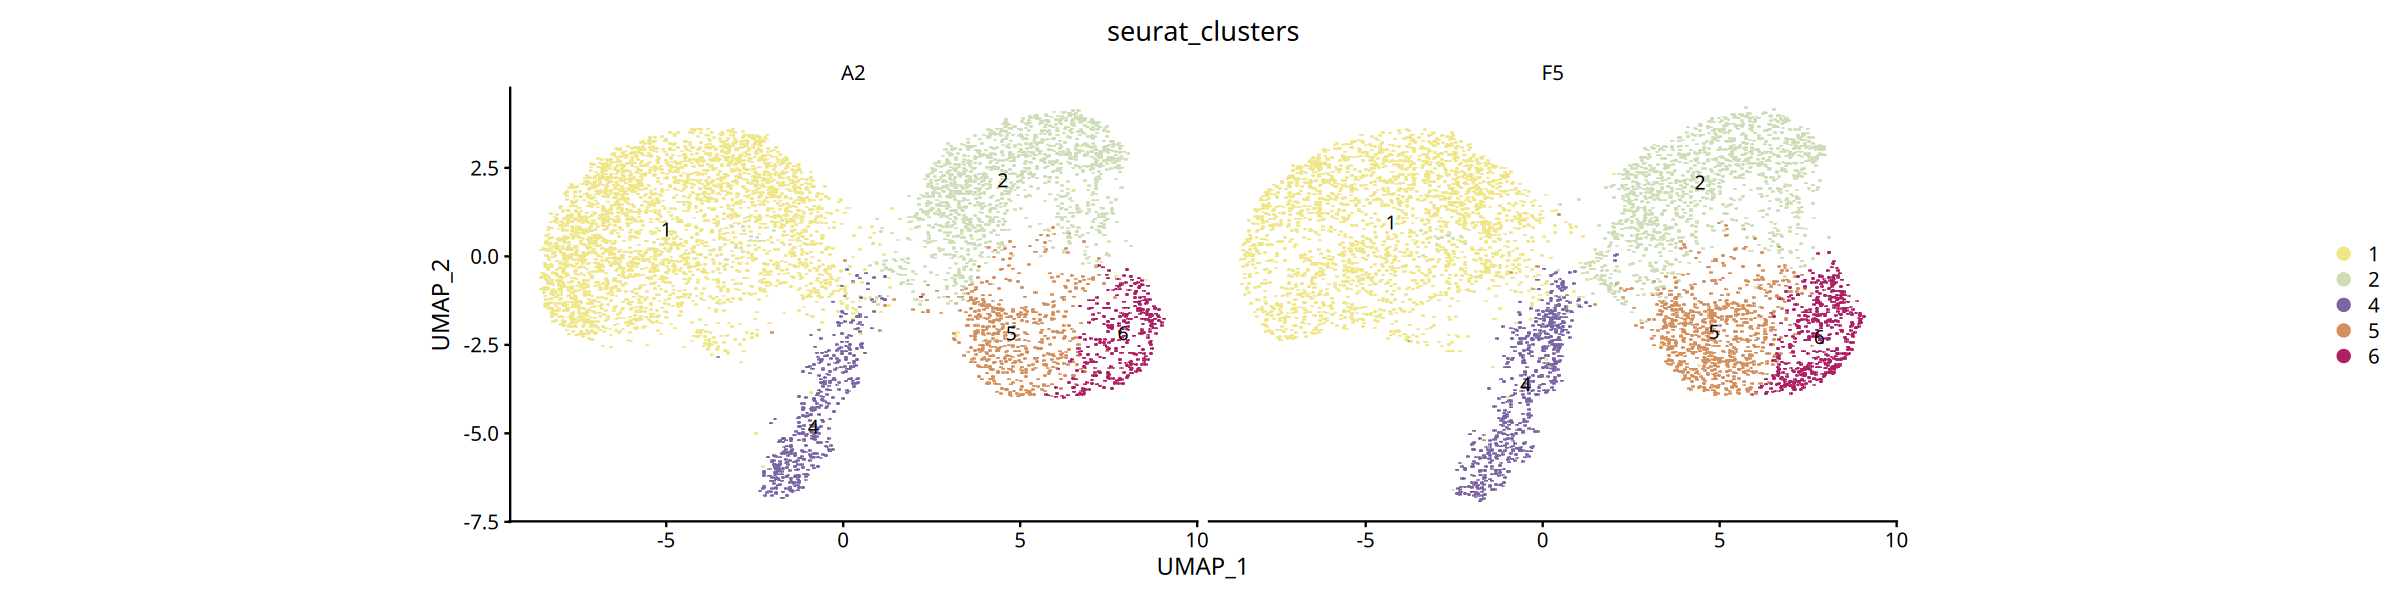

In [110]:
options(repr.plot.height=5,repr.plot.width=20)
p <- DimPlot(obj_turt_ST,reduction = 'umap',split.by = 'sample',pt.size = 2,raster=T,group.by='seurat_clusters',label=T)+
scale_color_manual(values = pal_igv()(50)[c(4,18,15,14,20,7)],breaks = sort(unique(obj_turt_ST$seurat_clusters)))+
coord_fixed()
p

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


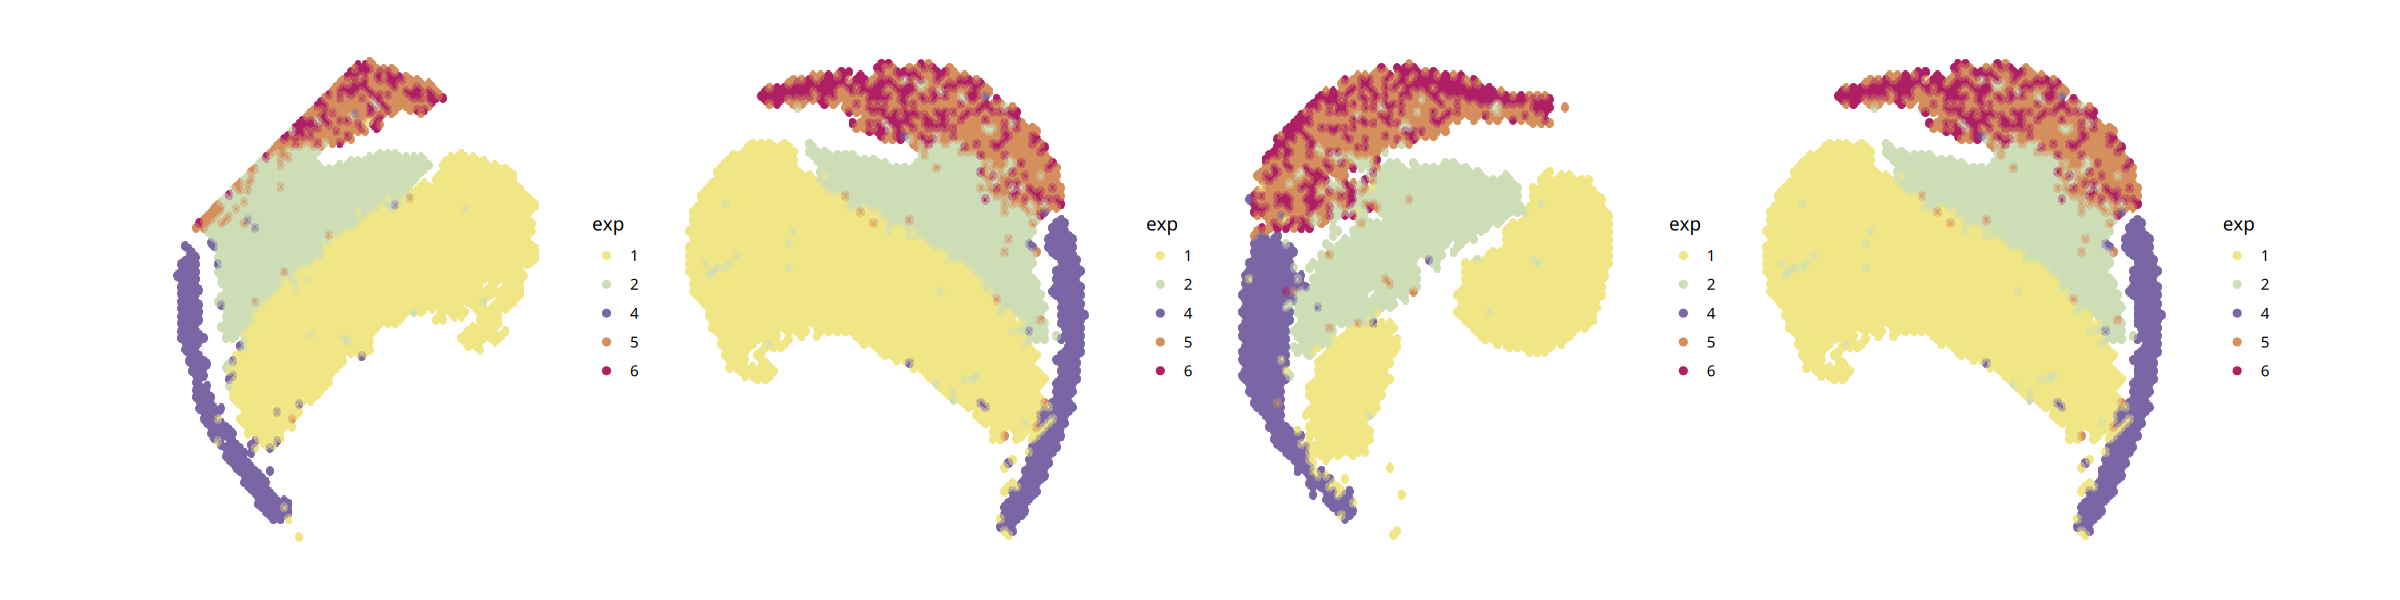

In [111]:
options(repr.plot.height=5,repr.plot.width=20)
p1 <- plot_spatial_col(obj = obj_turt_ST@meta.data[obj_turt_ST$sample=='A2'&obj_turt_ST$type=='left',],size = 5,col_name = 'seurat_clusters')+
scale_color_manual(values = pal_igv()(50)[c(4,18,15,14,20,7)],breaks = sort(unique(obj_turt_ST$seurat_clusters)))
p2 <- plot_spatial_col(obj = obj_turt_ST@meta.data[obj_turt_ST$sample=='A2'&obj_turt_ST$type=='right',],size = 5,col_name = 'seurat_clusters')+
scale_color_manual(values = pal_igv()(50)[c(4,18,15,14,20,7)],breaks = sort(unique(obj_turt_ST$seurat_clusters)))
p3 <- plot_spatial_col(obj = obj_turt_ST@meta.data[obj_turt_ST$sample=='F5'&obj_turt_ST$type=='left',],size = 5,col_name = 'seurat_clusters')+
scale_color_manual(values = pal_igv()(50)[c(4,18,15,14,20,7)],breaks = sort(unique(obj_turt_ST$seurat_clusters)))
p4 <- plot_spatial_col(obj = obj_turt_ST@meta.data[obj_turt_ST$sample=='A2'&obj_turt_ST$type=='right',],size = 5,col_name = 'seurat_clusters')+
scale_color_manual(values = pal_igv()(50)[c(4,18,15,14,20,7)],breaks = sort(unique(obj_turt_ST$seurat_clusters)))
p1+p2+p3+p4+plot_layout(ncol = 4)

In [12]:
source('../R_function/ST_plot.R')

pdf 
  2

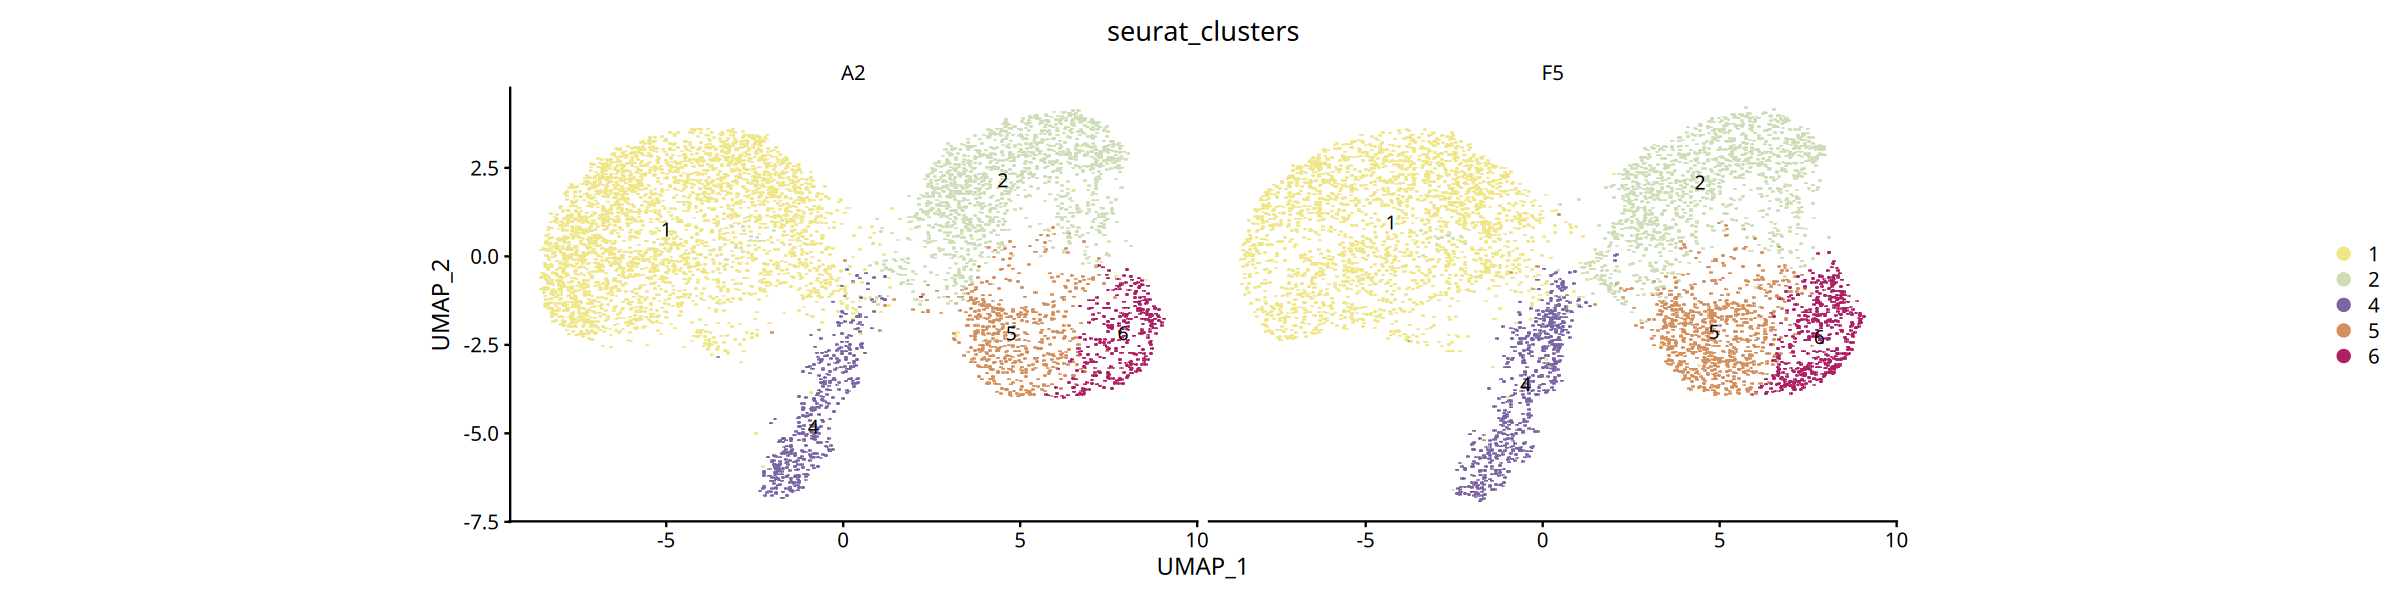

In [98]:
options(repr.plot.height=5,repr.plot.width=20)
p <- DimPlot(obj_turt_ST,reduction = 'umap',split.by = 'sample',pt.size = 2,raster=T,group.by='seurat_clusters',label=T)+
scale_color_manual(values = pal_igv()(50)[c(4,18,15,14,20,7)],breaks = sort(unique(obj_turt_ST$seurat_clusters)))+
coord_fixed()
p
pdf('Plot/Region_cluster/Turt_umap_cluster.pdf',height = 5,width = 20)
p
dev.off()

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


pdf 
  2

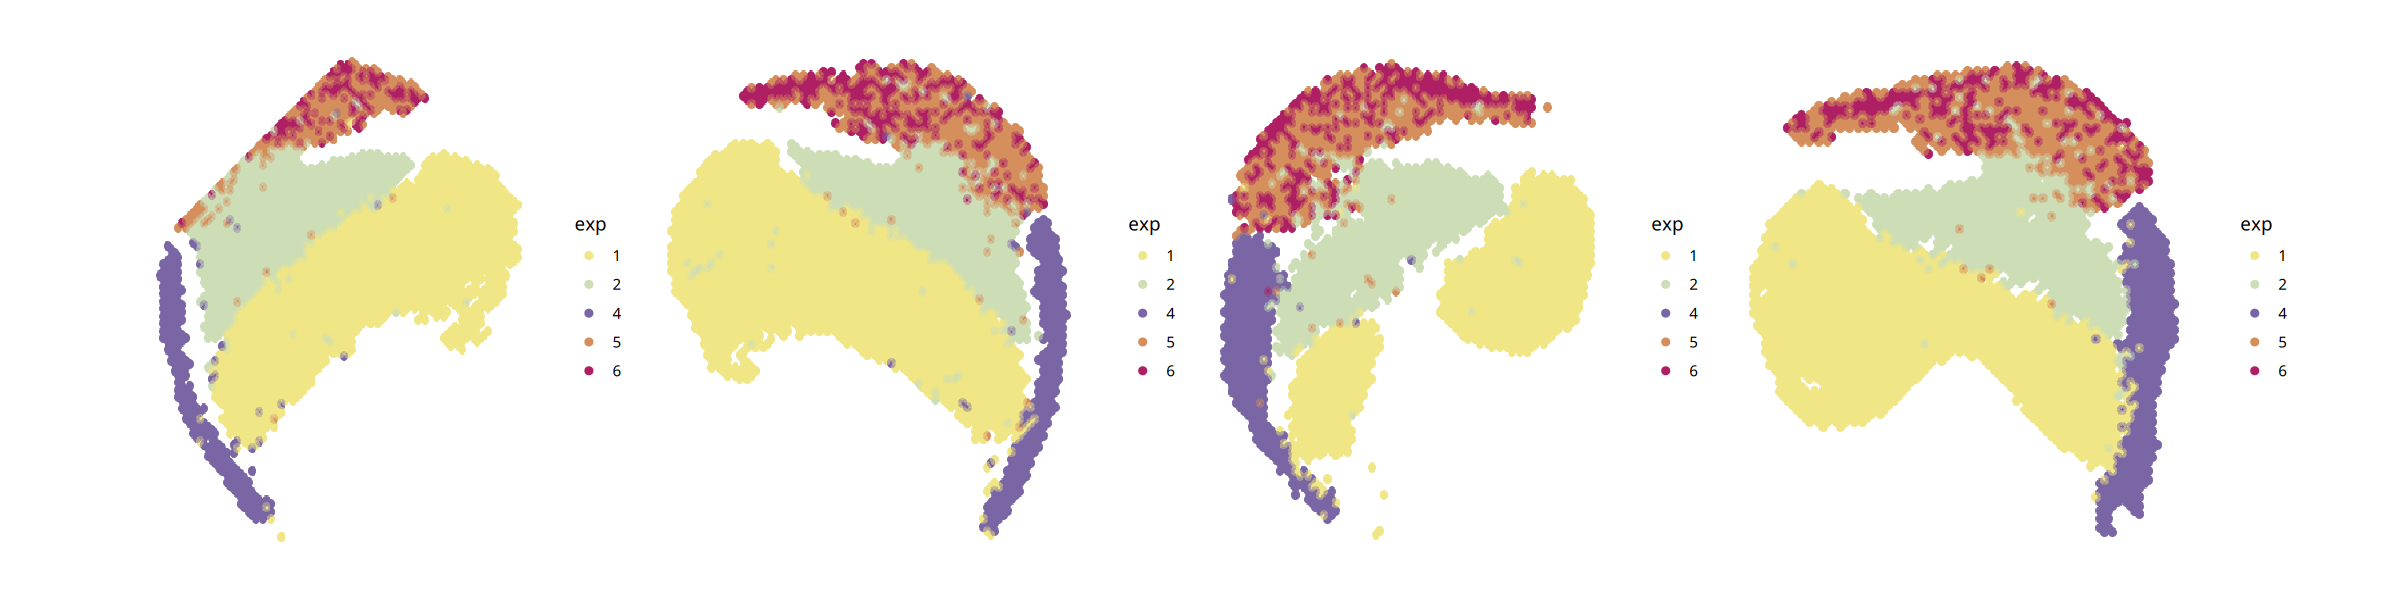

In [129]:
options(repr.plot.height=5,repr.plot.width=20)
p1 <- plot_spatial_col(obj = obj_turt_ST@meta.data[obj_turt_ST$sample=='A2'&obj_turt_ST$type=='left',],size = 5,col_name = 'seurat_clusters')+
scale_color_manual(values = pal_igv()(50)[c(4,18,15,14,20,7)],breaks = sort(unique(obj_turt_ST$seurat_clusters)))
p2 <- plot_spatial_col(obj = obj_turt_ST@meta.data[obj_turt_ST$sample=='A2'&obj_turt_ST$type=='right',],size = 5,col_name = 'seurat_clusters')+
scale_color_manual(values = pal_igv()(50)[c(4,18,15,14,20,7)],breaks = sort(unique(obj_turt_ST$seurat_clusters)))
p3 <- plot_spatial_col(obj = obj_turt_ST@meta.data[obj_turt_ST$sample=='F5'&obj_turt_ST$type=='left',],size = 5,col_name = 'seurat_clusters')+
scale_color_manual(values = pal_igv()(50)[c(4,18,15,14,20,7)],breaks = sort(unique(obj_turt_ST$seurat_clusters)))
p4 <- plot_spatial_col(obj = obj_turt_ST@meta.data[obj_turt_ST$sample=='F5'&obj_turt_ST$type=='right',],size = 5,col_name = 'seurat_clusters')+
scale_color_manual(values = pal_igv()(50)[c(4,18,15,14,20,7)],breaks = sort(unique(obj_turt_ST$seurat_clusters)))
p1+p2+p3+p4+plot_layout(ncol = 4)
pdf('Plot/Region_cluster/Turt_spatial_cluster.pdf',height = 5,width = 20)
p1+p2+p3+p4+plot_layout(ncol = 4)
dev.off()

In [4]:
obj_turt_ST <- readRDS('Analysis/Region_defined/Gene_turt.rds')

In [105]:
source('../R_function/ST_plot.R')

In [112]:
p1 <- plot_spatial_col(obj = obj_turt_ST@meta.data[obj_turt_ST$sample=='A2',],size = 5,col_name = 'seurat_clusters')+
scale_color_manual(values = pal_igv()(50)[c(4,18,15,14,20,7)],breaks = sort(unique(obj_turt_ST$seurat_clusters)))
p2 <- plot_spatial_col(obj = obj_turt_ST@meta.data[obj_turt_ST$sample=='F5',],size = 5,col_name = 'seurat_clusters')+
scale_color_manual(values = pal_igv()(50)[c(4,18,15,14,20,7)],breaks = sort(unique(obj_turt_ST$seurat_clusters)))
save_real_plot(p1,dir_path = 'Plot/Region_mask/',name = 'turt_A2',plot_x_vector = obj_turt_ST@meta.data[obj_turt_ST$sample=='A2',]$x,plot_y_vector = obj_turt_ST@meta.data[obj_turt_ST$sample=='A2',]$y,edge_add = 50)
save_real_plot(p2,dir_path = 'Plot/Region_mask/',name = 'turt_F5',plot_x_vector = obj_turt_ST@meta.data[obj_turt_ST$sample=='F5',]$x,plot_y_vector = obj_turt_ST@meta.data[obj_turt_ST$sample=='F5',]$y,edge_add = 50)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Coordinate system already present. Adding new coordinate system, which will
replace the existing one.
Coordinate system already present. Adding new coordinate system, which will
replace the existing one.


In [126]:
turt_mask1 <- read_real_mask_plot('Plot/Region_mask/turt_A2_mask_-141.92_49.7.tif',x_offset = -141.92, y_offset = 49.7)
turt_mask2 <- read_real_mask_plot('Plot/Region_mask/turt_F5_mask_-24.54_-92.43.tif',x_offset = -24.54, y_offset = -92.43)
turt_mask1$region <- c('255'='aDVR','200'='LC','150'='lDC','100'='PT','50'='mDC')[as.character(turt_mask1$mask)]
turt_mask2$region <- c('255'='aDVR','200'='LC','150'='lDC','100'='PT','50'='mDC')[as.character(turt_mask2$mask)]
obj_turt_ST@meta.data$region <- NA
obj_turt_ST@meta.data$region <- NA
obj_turt_ST@meta.data[obj_turt_ST$sample=='A2',] <- df_add_mask(obj_turt_ST@meta.data[obj_turt_ST$sample=='A2',],turt_mask1,imputation = T,mask_col = 'region')
obj_turt_ST@meta.data[obj_turt_ST$sample=='F5',] <- df_add_mask(obj_turt_ST@meta.data[obj_turt_ST$sample=='F5',],turt_mask2,imputation = T,mask_col = 'region')

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


pdf 
  2

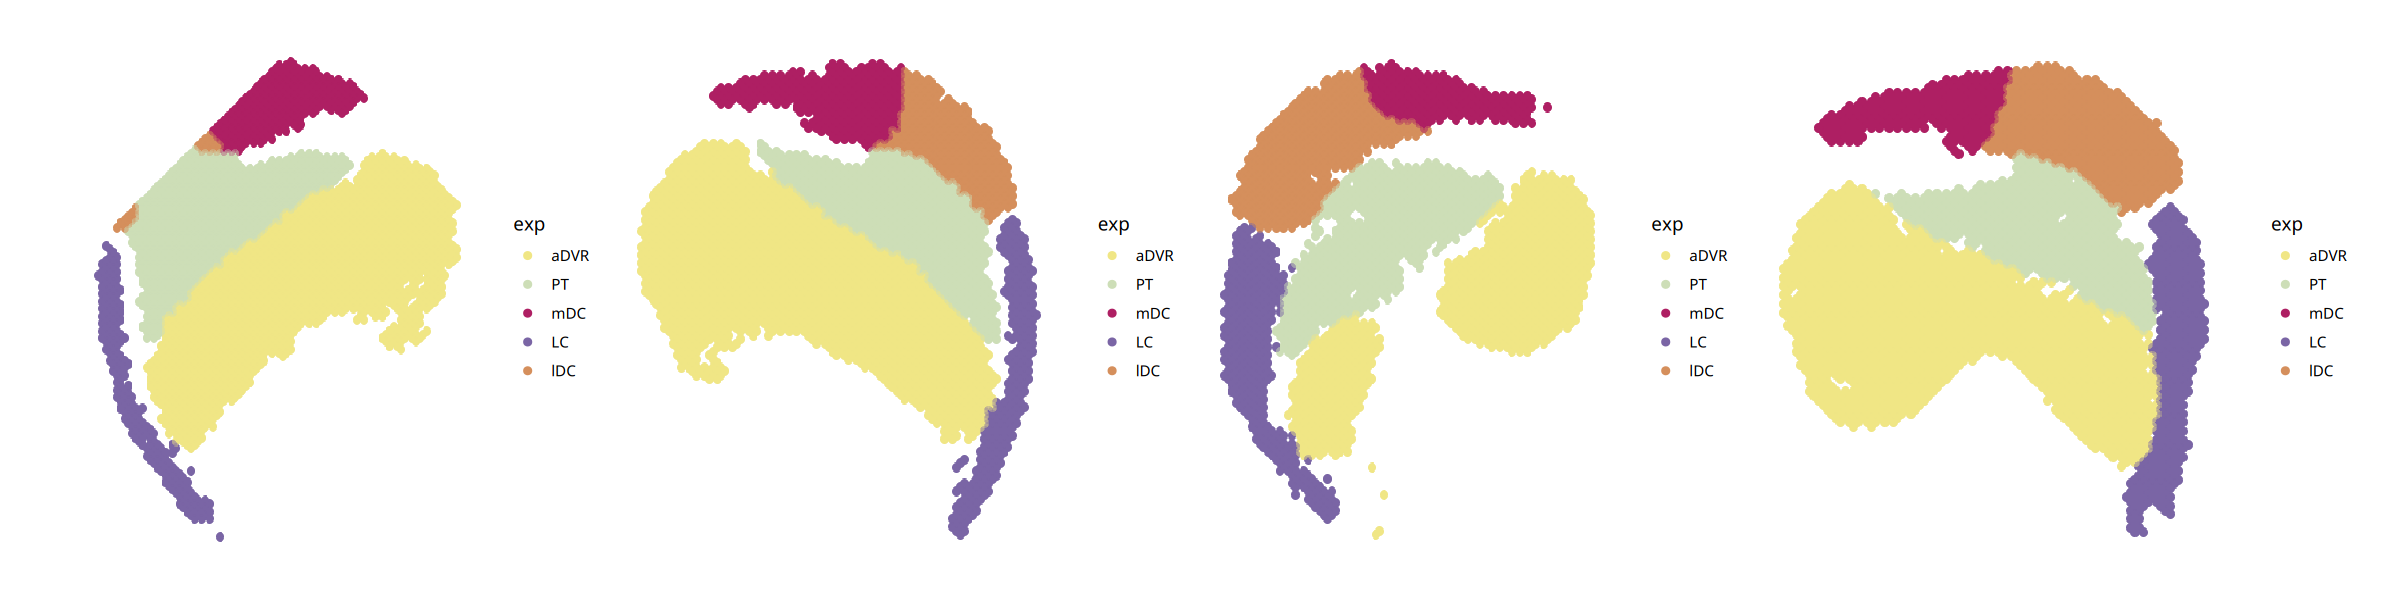

In [7]:
options(repr.plot.height=5,repr.plot.width=20)
p1 <- plot_spatial_col(obj = obj_turt_ST@meta.data[obj_turt_ST$sample=='A2'&obj_turt_ST$type=='left',],size = 5,col_name = 'region')+
scale_color_manual(values = pal_igv()(50)[c(4,18,20,15,14)],breaks = c('aDVR','PT','mDC','LC','lDC'))
p2 <- plot_spatial_col(obj = obj_turt_ST@meta.data[obj_turt_ST$sample=='A2'&obj_turt_ST$type=='right',],size = 5,col_name = 'region')+
scale_color_manual(values = pal_igv()(50)[c(4,18,20,15,14)],breaks = c('aDVR','PT','mDC','LC','lDC'))
p3 <- plot_spatial_col(obj = obj_turt_ST@meta.data[obj_turt_ST$sample=='F5'&obj_turt_ST$type=='left',],size = 5,col_name = 'region')+
scale_color_manual(values = pal_igv()(50)[c(4,18,20,15,14)],breaks = c('aDVR','PT','mDC','LC','lDC'))
p4 <- plot_spatial_col(obj = obj_turt_ST@meta.data[obj_turt_ST$sample=='F5'&obj_turt_ST$type=='right',],size = 5,col_name = 'region')+
scale_color_manual(values = pal_igv()(50)[c(4,18,20,15,14)],breaks = c('aDVR','PT','mDC','LC','lDC'))
p1+p2+p3+p4+plot_layout(ncol = 4)

pdf('Plot/Region_cluster/Turt_spatial_manual.pdf',height = 5,width = 20)
p1+p2+p3+p4+plot_layout(ncol = 4)
dev.off()

In [ ]:
impute_reduction <- obj_turt_ST@reductions$harmony
rownames(impute_reduction@cell.embeddings) <- paste0(gsub('_.*','',rownames(impute_reduction@cell.embeddings)),c('A2'='_turt_a2','F5'='_turt_f5')[obj_turt_ST$sample])
saveRDS( impute_reduction,'Analysis/Region_defined/Reduction_turt.rds')

In [128]:
saveRDS(obj_turt_ST,'Analysis/Region_defined/Gene_turt.rds')

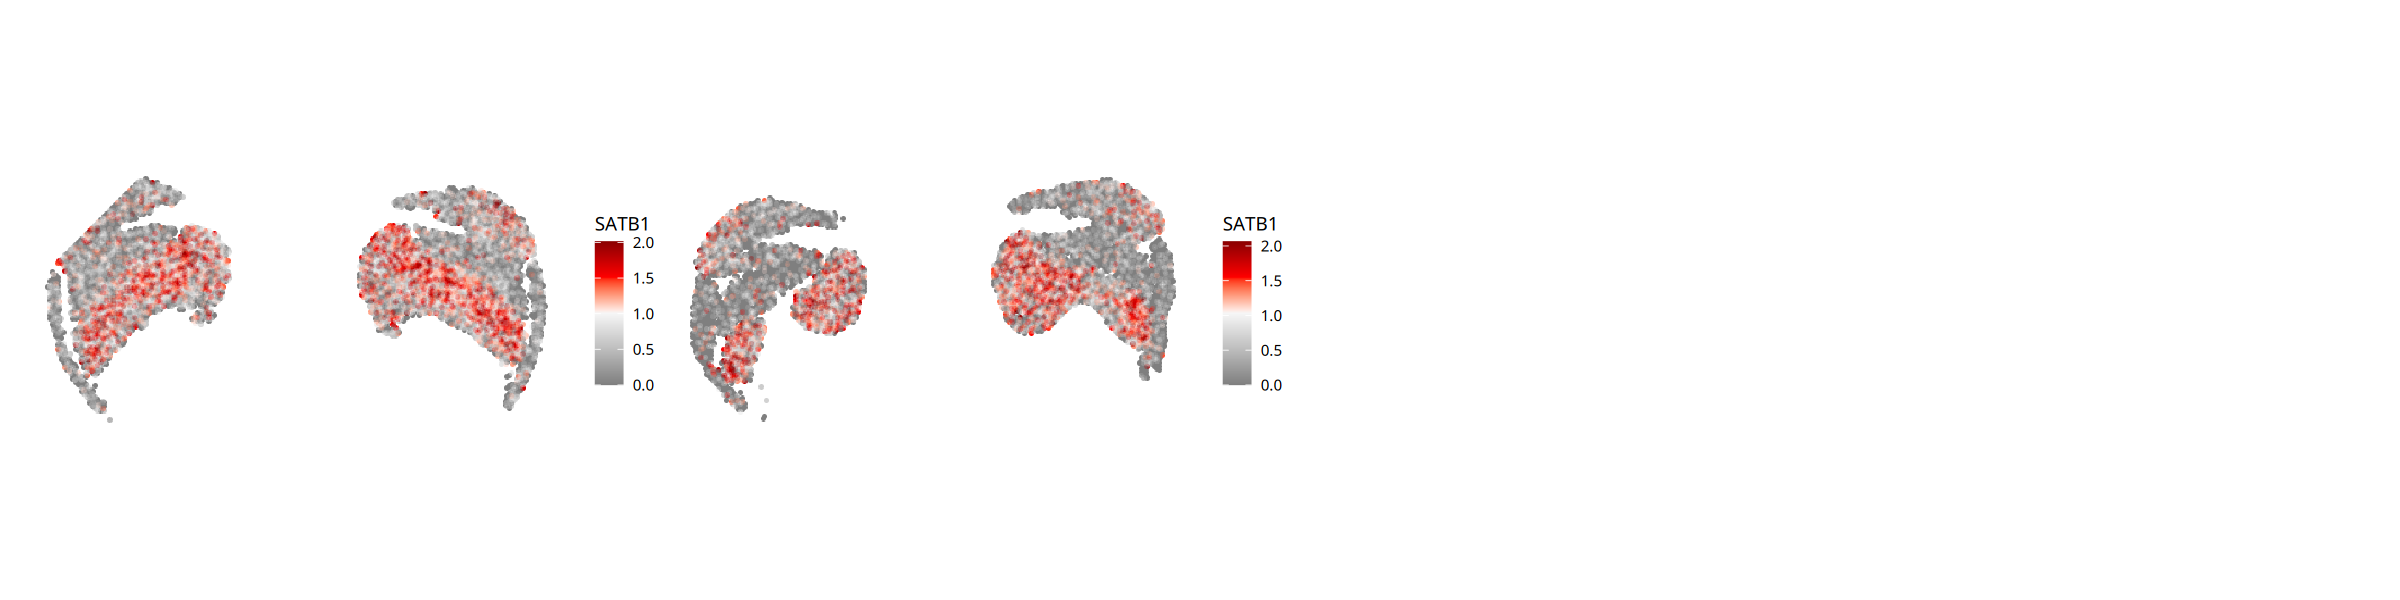

In [34]:
options(repr.plot.height=5,repr.plot.width=20)
p1 <- 
plot_spatial_feature(obj = obj_turt_ST_1,features = 'SATB1',height=200,assays='RNA',slot='data',max.cutoff = 0.99,smooth = F,knn=25,round=1,smooth_function='magic')+
plot_spatial_feature(obj = obj_turt_ST_2,features = 'SATB1',height=200,assays='RNA',slot='data',max.cutoff = 0.99,smooth = F,knn=25,round=1,smooth_function='magic')+
plot_layout(ncol = 3)
p1

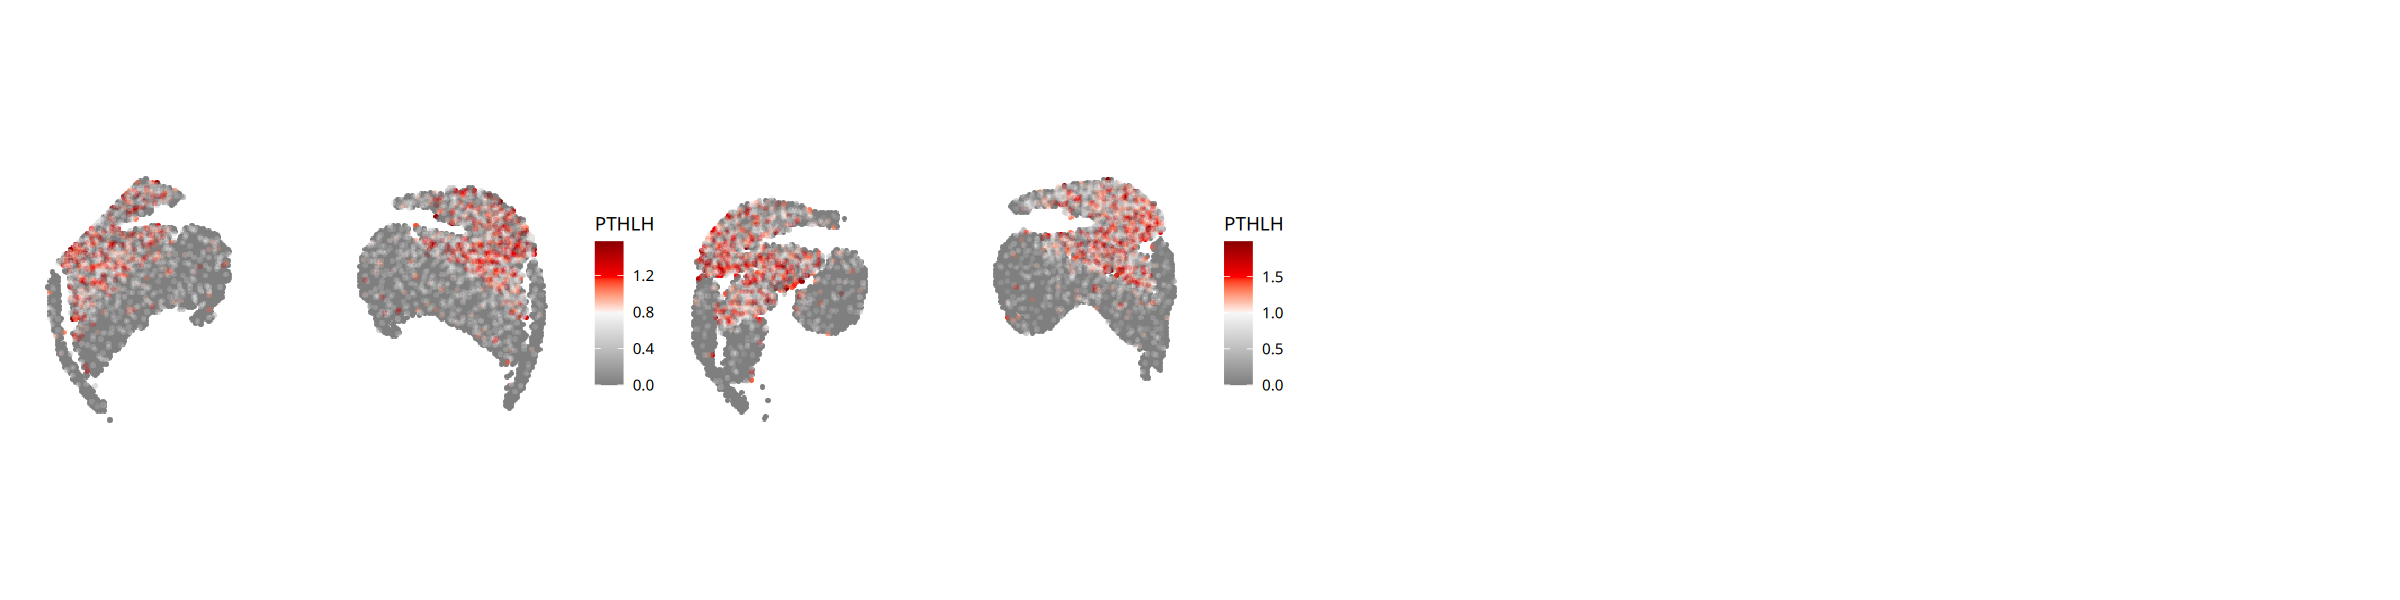

In [33]:
options(repr.plot.height=5,repr.plot.width=20)
p1 <- 
plot_spatial_feature(obj = obj_turt_ST_1,features = 'PTHLH',height=200,assays='RNA',slot='data',max.cutoff = 0.99,smooth = F,knn=25,round=1,smooth_function='magic')+
plot_spatial_feature(obj = obj_turt_ST_2,features = 'PTHLH',height=200,assays='RNA',slot='data',max.cutoff = 0.99,smooth = F,knn=25,round=1,smooth_function='magic')+
plot_layout(ncol = 3)
p1

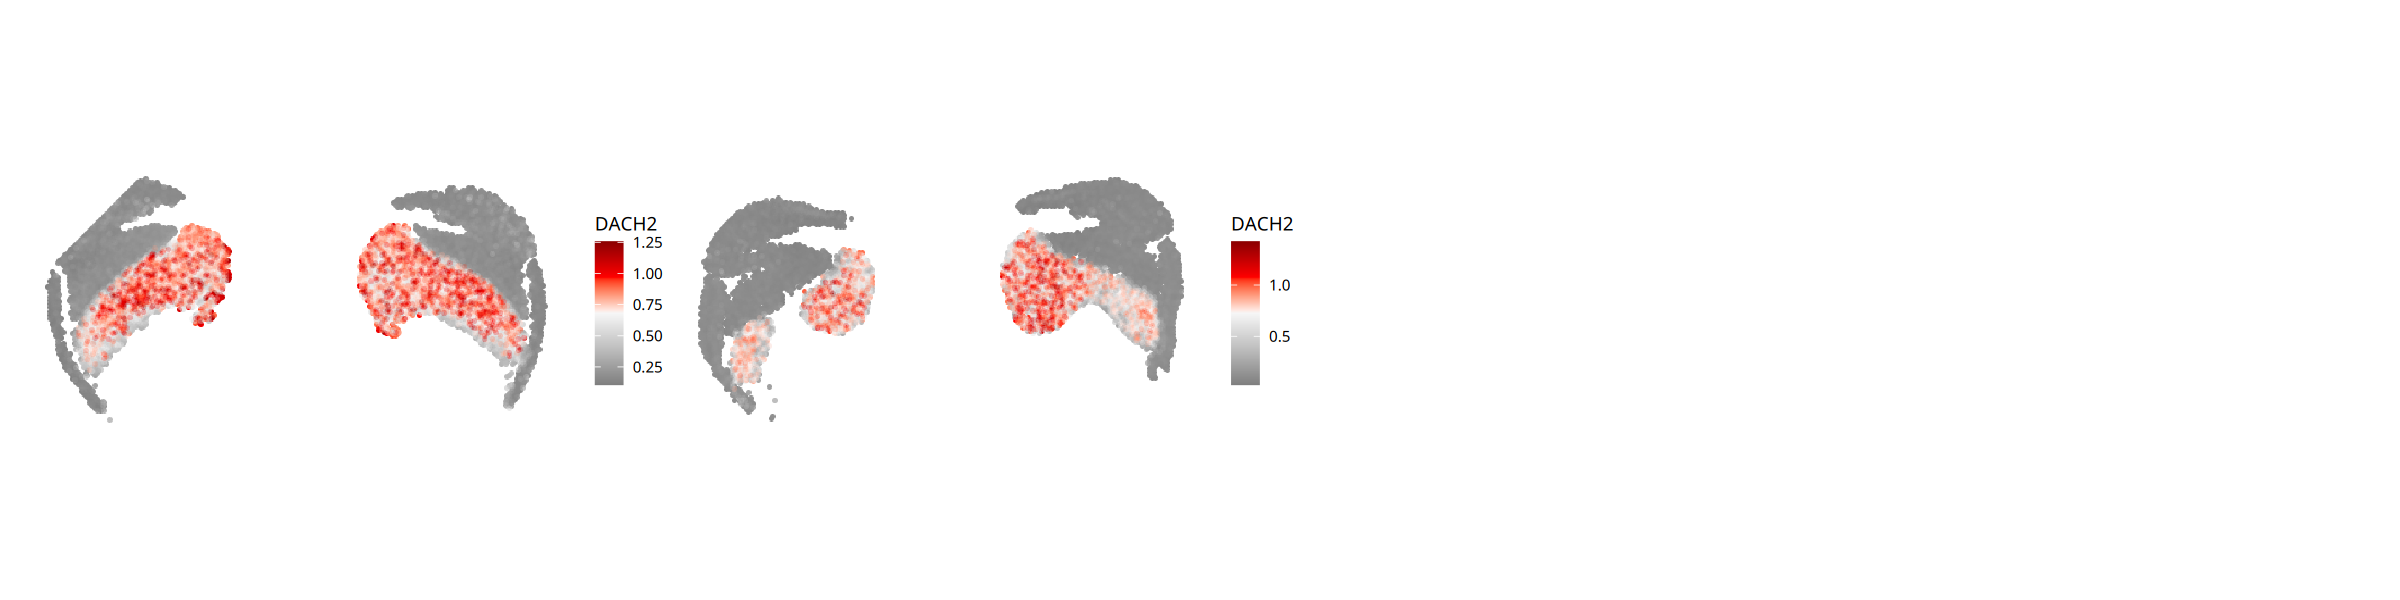

In [27]:
options(repr.plot.height=5,repr.plot.width=20)
p1 <- 
plot_spatial_feature(obj = obj_turt_ST_1,features = 'DACH2',height=200,assays='RNA',slot='data',smooth = T,knn=25,round=1,smooth_function='magic')+
plot_spatial_feature(obj = obj_turt_ST_2,features = 'DACH2',height=200,assays='RNA',slot='data',smooth = T,knn=25,round=1,smooth_function='magic')+
plot_layout(ncol = 3)
p1

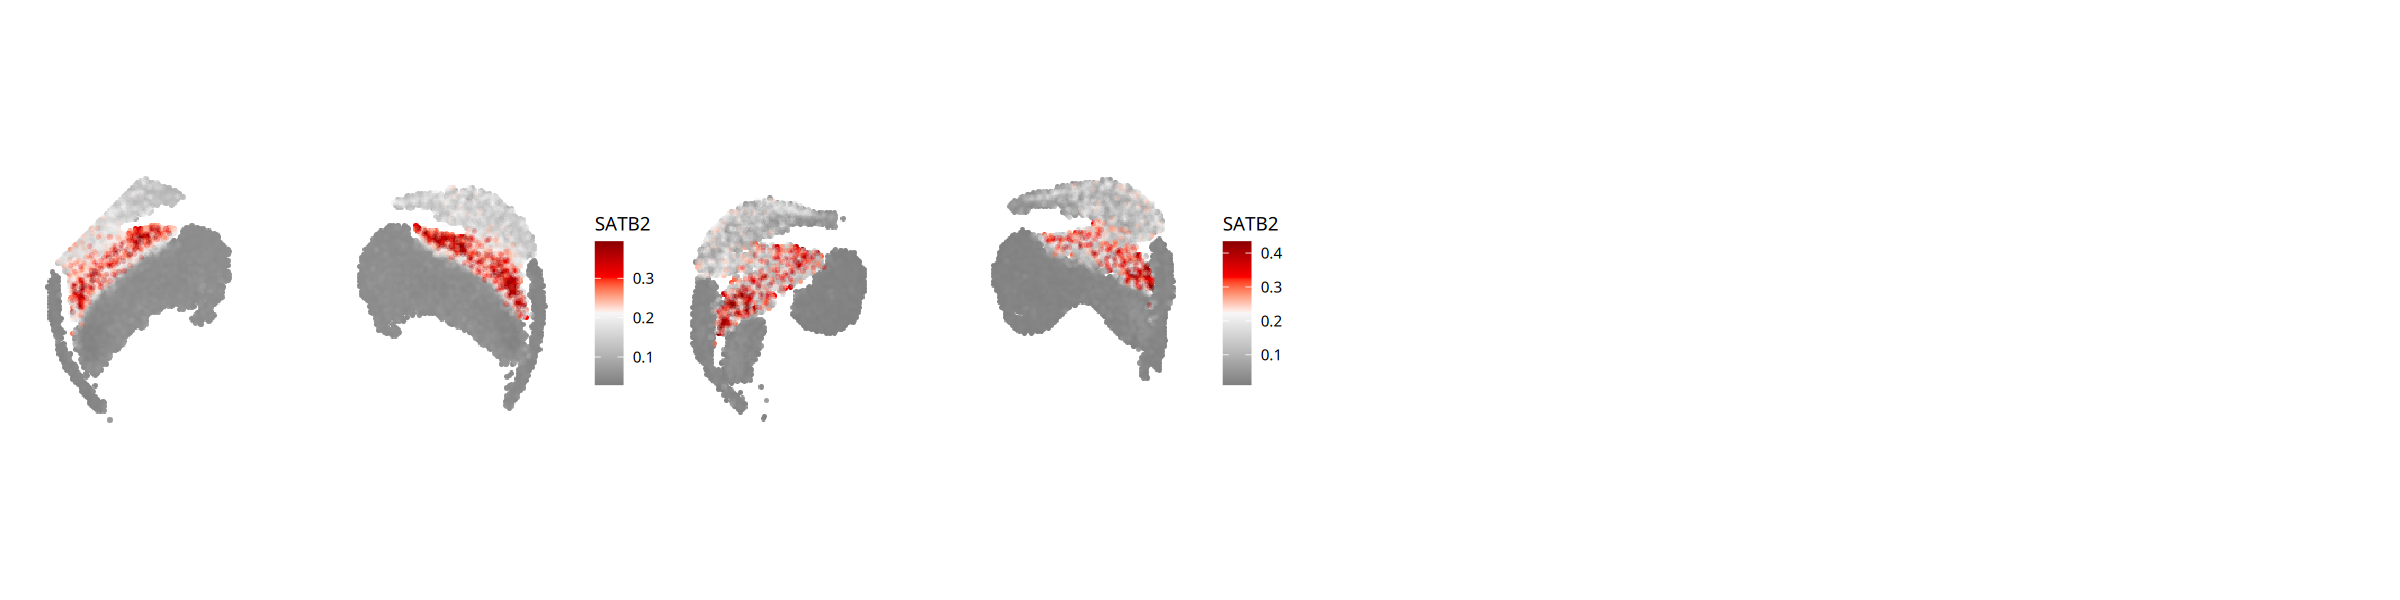

In [28]:
options(repr.plot.height=5,repr.plot.width=20)
p2 <- 
plot_spatial_feature(obj = obj_turt_ST_2,features = 'SATB2',height=200,assays='RNA',slot='data',smooth = T,max.cutoff=0.99,knn=25,round=3,smooth_function='magic')+
plot_spatial_feature(obj = obj_turt_ST_2,features = 'SATB2',height=200,assays='RNA',slot='data',smooth = T,max.cutoff=0.99,knn=25,round=3,smooth_function='magic')+
plot_layout(ncol = 3)
p2

In [29]:
pdf('Plot/Region_gene_plot/Turt_DACH2.pdf',width=20,height = 5)
p1
dev.off()
pdf('Plot/Region_gene_plot/Turt_SATB2.pdf',width=20,height = 5)
p2
dev.off()

pdf 
  2

pdf 
  2